Notebook to generate the figures in the readme.md

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd 
import matplotlib as mpl
import matplotlib.pyplot as plt 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import Polygon, MultiPolygon
from textwrap import fill
from matplotlib.colors import TwoSlopeNorm
import dataframe_image as dfi
from textwrap import fill
import colorcet as cc
from aux_func import code_to_state, state_to_code, estado_para_regiao, rename_models

# Definir a cor das bordas (spines) como cinza
mpl.rcParams['axes.edgecolor'] = 'gray'

# Definir a cor das linhas dos ticks maiores e menores como cinza
mpl.rcParams['xtick.color'] = 'gray'
mpl.rcParams['ytick.color'] = 'gray'
mpl.rcParams['xtick.labelcolor'] = 'black'
mpl.rcParams['ytick.labelcolor'] = 'black'
plt.rcParams['axes.labelsize'] = 16 # Axis labels
plt.rcParams['xtick.labelsize'] = 14  # X-axis tick labels
plt.rcParams['ytick.labelsize'] = 14  # Y-axis tick labels
plt.rcParams['font.size'] = 16  # General font size
FONT = 12

In [2]:
challenge = 'chik_state'

df_preds = pd.read_csv(f'./predictions/predictions_all_models_{challenge}.csv.gz', index_col = 'Unnamed: 0')
df_preds.date = pd.to_datetime(df_preds.date)
df_preds = df_preds.loc[df_preds.adm_1 != 32]
df_preds.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,adm_1,id,validation,wis,model
0,2022-10-09,2.743512,3.561896,5.283421,9.016248,17.670073,40.444549,89.679029,143.716210,206.231430,33,5354,1,82.77,3rd_imdc_emap_lstm
1,2022-10-16,3.743952,5.428969,6.920945,12.201003,27.237822,55.050853,112.596736,216.009888,325.011995,33,5354,1,82.77,3rd_imdc_emap_lstm
2,2022-10-23,4.875423,5.693745,8.176445,12.618417,22.377075,42.060248,77.746351,114.612724,173.066908,33,5354,1,82.77,3rd_imdc_emap_lstm
3,2022-10-30,3.250737,4.192324,5.602107,9.793079,17.521617,34.101676,68.882955,117.519627,166.359700,33,5354,1,82.77,3rd_imdc_emap_lstm
4,2022-11-06,2.961620,3.732665,5.172567,9.438648,20.027886,46.905846,103.815092,215.222367,336.458355,33,5354,1,82.77,3rd_imdc_emap_lstm


In [3]:
df_rank = pd.read_csv(f'predictions/rank_ratio_{challenge}.csv.gz')

df_rank['model'] = df_rank['model'].replace(rename_models)

df_rank['rank'] = df_rank.groupby(['validation', 'adm_1'])['wis_ratio'].rank(ascending=True, method='min')
#df_rank['region'] = df_rank['region'].replace(rename_regions)

df_rank = df_rank.loc[df_rank.adm_1 != 32]

df_rank.head()

,model,adm_1,validation,wis,wis_baseline,wis_ratio,region,rank
0,EMAP_PROPHET,11,1,1.102423,1.225200,0.899790,North,5.0
1,EMAP_PROPHET,11,2,2.192259,1.865080,1.175424,North,2.0
2,EMAP_PROPHET,11,3,79.200000,80.320000,0.986056,North,4.0
3,EMAP_PROPHET,11,4,12.900000,10.390000,1.241578,North,5.0
4,EMAP_PROPHET,12,1,1.128754,1.159976,0.973084,North,7.0


In [4]:
df_rank.model.unique()

<ArrowStringArray>
[ 'EMAP_PROPHET',  'EMAP_SARIMAX',     'EMAP_LSTM',      'EMAP_XGB',
    'LNCC_ARP26', 'LNCC_CLIDENGO',    'LNCC_SURGE',      'NUS-CERM',
         'PROCC',        'PURDUE',    'DS-OKSTATE']
Length: 11, dtype: str

Get colors:

In [5]:
keys = df_rank.model.unique()

n = len(keys)

colors = cc.glasbey[:30]
color_palette = dict(zip(keys, colors))

## Plots Best models by state: 

In [6]:
df_summary = (
    df_rank
    .groupby(["adm_1", "model"], as_index=False)
    .agg(
        geometric_mean_ratio=("wis_ratio", lambda x: np.exp(np.mean(np.log(x)))),
    )
    .sort_values(["adm_1", "geometric_mean_ratio"])
)

column = 'geometric_mean_ratio'

df_summary["rank"] = (
    df_summary.groupby(["adm_1"])[[column]].rank(method="min", ascending=True)
)


df_bm_st = df_summary.loc[df_summary['rank'] ==1].rename(columns = {'model': 'best_model'})
df_bm_st['state'] = df_bm_st['adm_1'].replace(code_to_state)

df_bm_st.head()

,adm_1,best_model,geometric_mean_ratio,rank,state
9,11,PROCC,1.000000,1.0,RO
21,12,PURDUE,0.862730,1.0,AC
24,13,EMAP_PROPHET,0.949956,1.0,AM
38,14,LNCC_ARP26,0.416065,1.0,RR
49,15,LNCC_ARP26,0.263101,1.0,PA


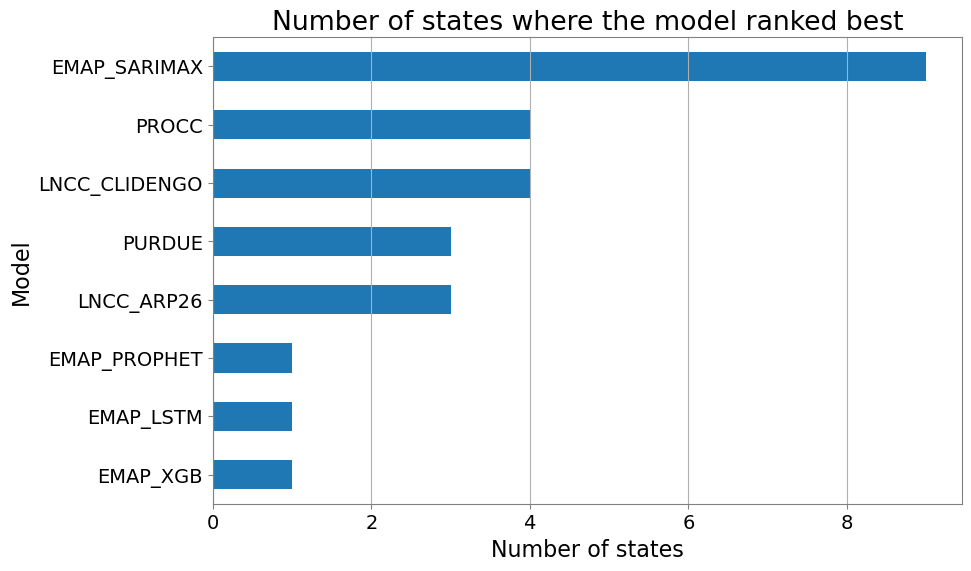

In [7]:
counts = df_bm_st.best_model.value_counts()

# Plot horizontal bar chart
counts.plot(kind="barh", figsize=(10,6))

plt.ylabel("Model")
plt.xlabel("Number of states")
plt.title("Number of states where the model ranked best")
plt.gca().invert_yaxis()  # optional: puts the highest bar at the top
plt.grid(axis='x')
plt.tight_layout()
plt.savefig(f'figures/count_best_models_state_{challenge}.png', dpi=300, bbox_inches='tight')
plt.show()

Plot map: 

In [8]:
def remove_holes(geom):
    if geom.geom_type == "Polygon":
        return Polygon(geom.exterior)  # mantém só o contorno externo
    elif geom.geom_type == "MultiPolygon":
        # acessa cada polígono dentro do MultiPolygon
        return MultiPolygon([Polygon(p.exterior) for p in geom.geoms])
    else:
        return geom

In [9]:
df_muni = gpd.read_file('../imdc_2026/data/shape_muni.gpkg')

df_muni["geometry"] = df_muni.buffer(0)

df_uf = df_muni.dissolve(by="uf")

df_uf["geometry"] = df_uf["geometry"].apply(remove_holes)

df_uf["geometry"] = df_uf.buffer(1e-9).buffer(-1e-9)

# reset index if you want 'uf' back as a column
df_uf = df_uf.reset_index()

df_uf_m = df_uf.merge(df_bm_st, left_on = 'uf', right_on = 'state')

df_uf_m.head()

/tmp/ipykernel_6101/1175374976.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df_uf["geometry"] = df_uf.buffer(1e-9).buffer(-1e-9)


,uf,geometry,geocode,geocode_name,uf_code,adm_1,best_model,geometric_mean_ratio,rank,state
0,AC,"POLYGON ((-70.51515 -7.79238, -70.05498 -7.845...",1200013,Acrelândia,12,12,PURDUE,0.862730,1.0,AC
1,AL,"MULTIPOLYGON (((-38.23759 -9.3298, -38.23759 -...",2700102,Água Branca,27,27,EMAP_SARIMAX,0.677232,1.0,AL
2,AM,"POLYGON ((-72.37321 -4.83344, -72.37321 -4.833...",1300029,Alvarães,13,13,EMAP_PROPHET,0.949956,1.0,AM
3,AP,"MULTIPOLYGON (((-54.87625 2.42669, -54.87625 2...",1600055,Serra do Navio,16,16,LNCC_ARP26,0.715283,1.0,AP
4,BA,"MULTIPOLYGON (((-46.57715 -11.36086, -46.57715...",2900108,Abaíra,29,29,EMAP_SARIMAX,0.462367,1.0,BA


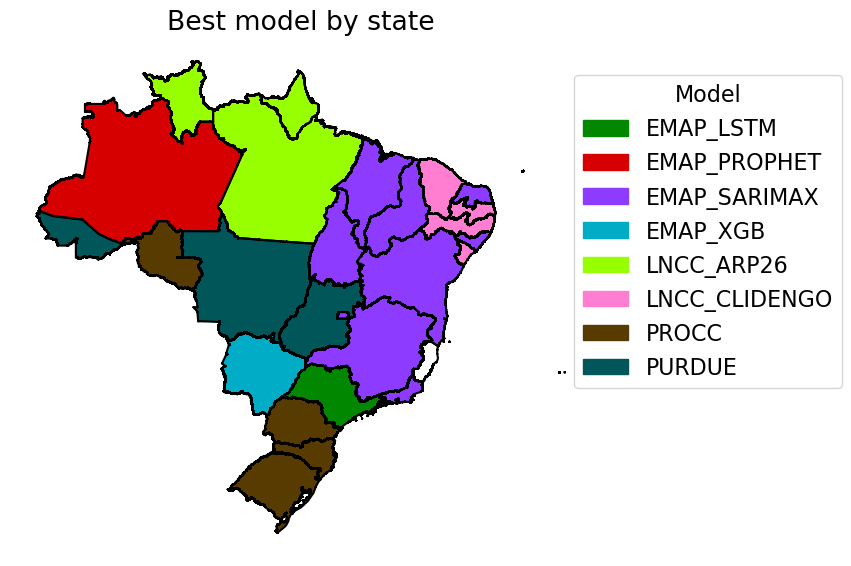

In [10]:
_, ax = plt.subplots(figsize = (7.5, 7.5))

handles = []  # aqui guardamos os patches da legenda

for model in np.sort(df_uf_m.best_model.unique()): 

    df_ = df_uf_m.loc[df_uf_m.best_model == model]
    
    #model = df_.best_model.values[0]

    df_.plot(color = color_palette[model], label = model, ax=ax)

    if not any(h.get_label() == model for h in handles):
        handles.append(mpatches.Patch(color=color_palette[model], label=model))

df_uf.boundary.plot(ax=ax, color = 'black')
ax.axis('off')

ax.legend(handles = handles, title = 'Model', bbox_to_anchor = (1.45, 0.95))

ax.set_title('Best model by state')

plt.savefig(f'figures/map_best_model_{challenge}.png', dpi = 400, bbox_inches = 'tight')
plt.show()

### Best model by region:

In [11]:
df_best_region_model = df_rank.groupby(["region", "model"], as_index=False).agg(
        arithmetic_mean_ratio=("wis_ratio", "mean"),
        geometric_mean_ratio=("wis_ratio", lambda x: np.exp(np.mean(np.log(x)))),
    ).sort_values(["region", "geometric_mean_ratio"]) 


df_best_region_model["rank"] = (
    df_best_region_model.groupby(["region"])[[column]].rank(method="min", ascending=True)
)

df_best_region_model.head()

,region,model,arithmetic_mean_ratio,geometric_mean_ratio,rank
10,Midwest,PURDUE,0.907974,0.832454,1.0
8,Midwest,NUS-CERM,1.009185,0.942076,2.0
3,Midwest,EMAP_SARIMAX,1.379711,0.988485,3.0
9,Midwest,PROCC,1.000000,1.000000,4.0
1,Midwest,EMAP_LSTM,1.258886,1.074723,5.0


### PLot Medal Board: 

In [12]:
df_top_3 = df_summary.loc[df_summary['rank'].isin([1, 2, 3])]
df_top_3['state'] = df_top_3['adm_1'].replace(code_to_state)

df_top_3.head()

,adm_1,model,geometric_mean_ratio,rank,state
9,11,PROCC,1.000000,1.0,RO
8,11,NUS-CERM,1.036956,2.0,RO
3,11,EMAP_SARIMAX,1.046410,3.0,RO
21,12,PURDUE,0.862730,1.0,AC
14,12,EMAP_SARIMAX,0.883114,2.0,AC


In [13]:
ranked_models = df_top_3.pivot(index='rank', columns='state', values='model')

ranked_models.head()

state,AC,AL,AM,AP,BA,CE,DF,GO,MA,MG,...,PR,RJ,RN,RO,RR,RS,SC,SE,SP,TO
rank,,,,,,,,,,,,,,,,,,,,,
1.0,PURDUE,EMAP_SARIMAX,EMAP_PROPHET,LNCC_ARP26,EMAP_SARIMAX,LNCC_CLIDENGO,EMAP_SARIMAX,PURDUE,EMAP_SARIMAX,EMAP_SARIMAX,...,PROCC,EMAP_SARIMAX,EMAP_SARIMAX,PROCC,LNCC_ARP26,PROCC,PROCC,LNCC_CLIDENGO,EMAP_LSTM,EMAP_SARIMAX
2.0,EMAP_SARIMAX,PURDUE,PROCC,EMAP_SARIMAX,PURDUE,EMAP_SARIMAX,PROCC,EMAP_XGB,PURDUE,PURDUE,...,PURDUE,LNCC_ARP26,LNCC_CLIDENGO,NUS-CERM,EMAP_SARIMAX,EMAP_PROPHET,EMAP_PROPHET,EMAP_SARIMAX,EMAP_SARIMAX,NUS-CERM
3.0,NUS-CERM,LNCC_CLIDENGO,EMAP_SARIMAX,PURDUE,EMAP_PROPHET,EMAP_XGB,EMAP_PROPHET,LNCC_SURGE,NUS-CERM,NUS-CERM,...,LNCC_SURGE,PURDUE,PURDUE,EMAP_SARIMAX,PURDUE,EMAP_SARIMAX,PURDUE,PURDUE,PROCC,EMAP_LSTM


In [14]:
def style_cells(val, 
                cell_colors = color_palette):
    """background das células de dados (mantém texto em negrito)."""
    bg = cell_colors.get(val, "white")
    return f"background-color: {bg}; font-weight: bold; text-align: center; color: black;"

def style_medal(val, medal_colors = {
    "GOLD":   "#DAA520",   # dourado
    "SILVER": "#B0B0B0",   # prata
    "BRONZE": "#A97142"    # bronze
}):
    """aplica cor apenas ao texto da coluna MEDAL."""
    c = medal_colors.get(val, "black")
    return f"color: {c}; font-weight: bold; text-align: left;"

def gen_table(ranked_models, index = ["GOLD", "SILVER", "BRONZE"]): 

    data = ranked_models

    df = pd.DataFrame(data.values, index=index, columns = data.columns)

    df.index.name = "MEDAL"

    df_reset = df.reset_index()   # agora há uma coluna "MEDAL" + as colunas originais

    styler = df_reset.style

    # estiliza todas as células de dados (todas colunas exceto 'MEDAL'):
    data_cols = [c for c in df_reset.columns if c != "MEDAL"]
    styler = styler.map(style_cells, subset=pd.IndexSlice[:, data_cols])

    # estiliza apenas a coluna MEDAL (texto colorido)
    styler = styler.map(style_medal, subset=pd.IndexSlice[:, ["MEDAL"]])

    # estilos gerais da tabela (bordas, fonte, cabeçalho)
    styler = styler.set_table_styles([
        {"selector": "th", "props": [("font-weight", "bold"), ("text-align", "center"), ("border", "1px solid black")]},
        {"selector": "td", "props": [("border", "1px solid black"), ("padding", "6px")]},
        {"selector": "table", "props": [("border-collapse", "collapse"), ("font-family", "Arial"), ("font-size", "13px")]}
    ])

    styler = styler.hide(axis="index")  # hides the index completely

    return styler

In [15]:

order = {
    'south': ['PR', 'SC' ,'RS'],
    'southeast': ['MG', 'RJ', 'SP'],
    'midwest': ['DF', 'GO', 'MT', 'MS'],
    'northeast': ['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE'],
    'north': ['AC', 'AM', 'AP', 'PA', 'RO', 'RR', 'TO'] } 

In [16]:
for region in order.keys(): 
    styler = gen_table(ranked_models[order[region]],) 
    dfi.export(styler, f"figures/medals_{region}_{challenge}.png", dpi = 400,  table_conversion="matplotlib",
)

### Models with mean ratio >1 

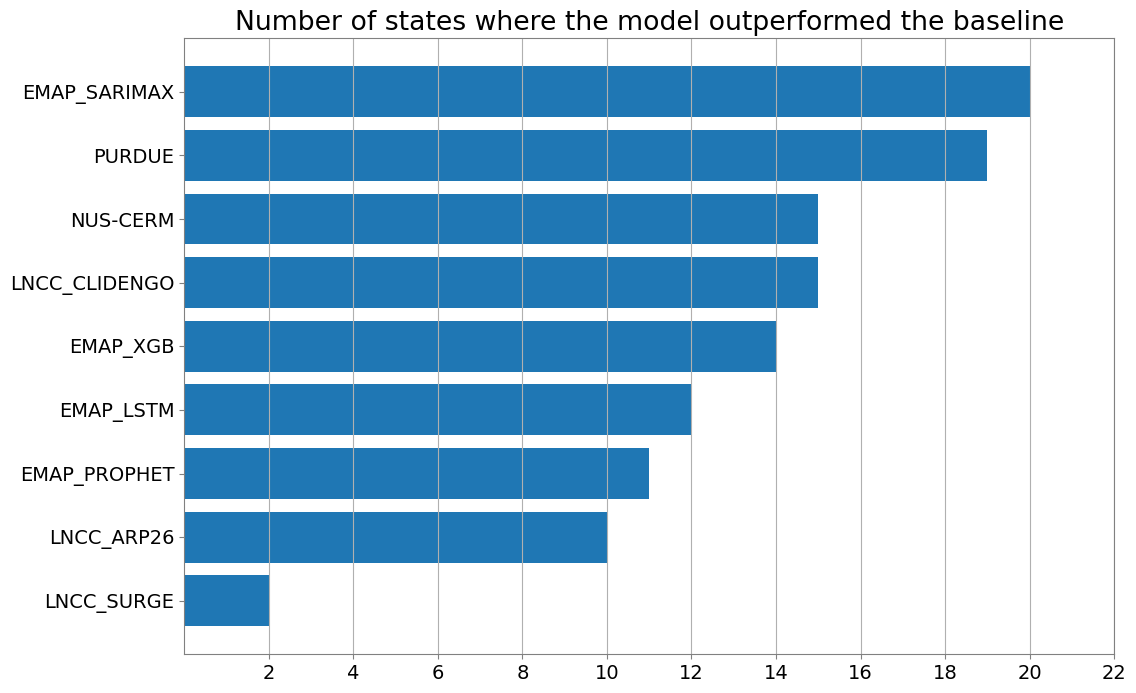

In [17]:
df_agg = df_summary.loc[df_summary.geometric_mean_ratio < 1].groupby(['model'])[['adm_1']].count()
df_agg = df_agg.sort_values(by = 'adm_1')

_, ax= plt.subplots(figsize = (12, 8))

ax.barh(df_agg.index, df_agg.adm_1)

ax.grid(axis = 'x')
ax.set_title('Number of states where the model outperformed the baseline')
ax.set_xticks(np.arange(2, 23, step = 2))

plt.savefig(f'figures/n_states_out_base_by_model_{challenge}.png', dpi = 400)

plt.show()

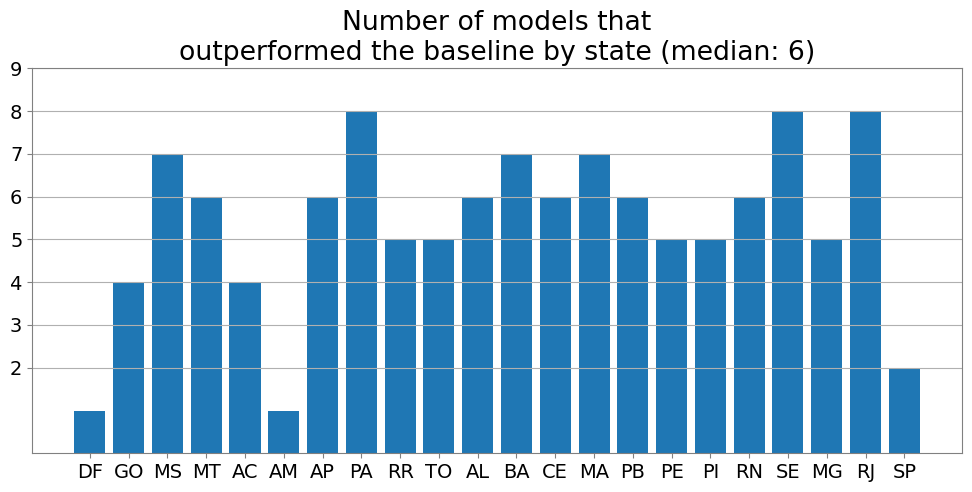

In [18]:
df_agg = df_summary.loc[df_summary.geometric_mean_ratio < 1].groupby(['adm_1'])[['model']].count().reset_index()
df_agg['adm_1'] = df_agg['adm_1'].replace(code_to_state)

# Cria a coluna de região e ordena
df_agg['regiao'] = df_agg['adm_1'].map(estado_para_regiao)
df_agg = df_agg.sort_values(by=['regiao', 'adm_1'])

# Plotagem
_, ax = plt.subplots(figsize=(12, 5))
ax.bar(df_agg.adm_1, df_agg.model)
ax.set_title(f'Number of models that\noutperformed the baseline by state (median: {int(np.median(df_agg.model))})')
ax.set_yticks(np.arange(2, 10, step = 1))

ax.grid(axis='y')

plt.savefig(f'figures/n_models_out_base_by_state_{challenge}.png', dpi = 400)

### Heatmaps

In [31]:
def plot_geometric_ratio_heatmap(
    df_summary,
    code_to_state,
    states,
    label,
    figsize=(25, 5),
):
    """
    Plot a heatmap of the geometric mean ratio by state and model.

    Parameters
    ----------
    df_summary : pd.DataFrame
        Summary dataframe containing 'adm_1', 'model' and
        'geometric_mean_ratio'.
    code_to_state : dict
        Dictionary mapping state codes to state abbreviations.
    states : list[str]
        States to include in the plot, in the desired order.
    label : str
        Output filename (without extension).
    figsize : tuple, optional
        Figure size.
    """

    df = df_summary.copy()
    df["state"] = df["adm_1"].replace(code_to_state)

    df_pivot = (
        df.loc[df["adm_1"] != 32]
        .pivot(index="state", columns="model", values="geometric_mean_ratio")
        .loc[states]
    )

    norm = TwoSlopeNorm(
        vmin=0.1,
        vcenter=1,
        vmax=2,
    )

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        df_pivot.values,
        cmap="RdYlGn_r",
        norm=norm,
        aspect="auto",
    )

    # Tick labels
    ax.set_xticks(np.arange(df_pivot.shape[1]))
    ax.set_yticks(np.arange(df_pivot.shape[0]))

    ax.set_xticklabels(
        [
            fill(col.replace("_", " "), width=18).replace(" ", "\n")
            for col in df_pivot.columns
        ]
    )
    ax.set_yticklabels(df_pivot.index)

    # Cell values
    for i in range(df_pivot.shape[0]):
        for j in range(df_pivot.shape[1]):
            ax.text(
                j,
                i,
                f"{df_pivot.iloc[i, j]:.2f}",
                ha="center",
                va="center",
                color="black",
            )

    #plt.colorbar(im, ax=ax, label="E_model / E_baseline")

    ax.set_xlabel("Model")
    ax.set_ylabel("State")
    ax.set_title(
        "Geometric mean of the ratio (E_model/E_baseline) across the four validation sets"
    )

    plt.setp(ax.get_xticklabels(), rotation=60, ha="right")

    fig.tight_layout()

    fig.savefig(f"figures/heatmap_{label}_{challenge}.png", dpi=300, bbox_inches="tight")
    plt.close(fig)

In [32]:
df_summary.geometric_mean_ratio.min()

np.float64(0.1974770104657524)

In [33]:
df_summary.geometric_mean_ratio.max()

np.float64(6.5508772125332655)

In [34]:
for region in order.keys(): 
    plot_geometric_ratio_heatmap(
        df_summary,
        code_to_state,
        order[region],
        region,
        figsize=(25, 5),
    )

### Rankplots: 

In [40]:
def plot_model_validation(
    df,
    colors,
    x_col,
    x_label,
    title,
    state=None,
    validation_ticks=[1, 2, 3, 4],
    figsize=(18, 7),
    x_ticks=None,
    x_lim=None,
    ncols_legend=6,
):
    
    df = df.loc[df.adm_1 == state]

    models = df.model.unique()

    _, ax = plt.subplots(figsize=figsize)

    for i, model in enumerate(models):
        df_to_plot = df.loc[df.model == model]

        ax.plot(
            df_to_plot[x_col],
            df_to_plot["validation"],
            color=colors[i],
            label=model,
            marker=".",
            markersize=15,
        )

    if x_ticks is not None:
        ax.set_xticks(x_ticks)

    ax.set_yticks(validation_ticks)

    ax.set_xlabel(x_label)
    ax.set_ylabel("Validation")

    if x_lim is not None:
        ax.set_xlim(x_lim)

    ax.grid(axis="y")

    ax.legend(
        loc=(0, -0.3),
        ncols=ncols_legend,
    )

    if state is not None:
        title = f"{title} in state: {code_to_state[state]}"

    ax.set_title(title)

    plt.savefig(f'figures/rankplot_{state}_{x_col}_{challenge}.png', dpi = 400, bbox_inches = 'tight')
    
    plt.show()

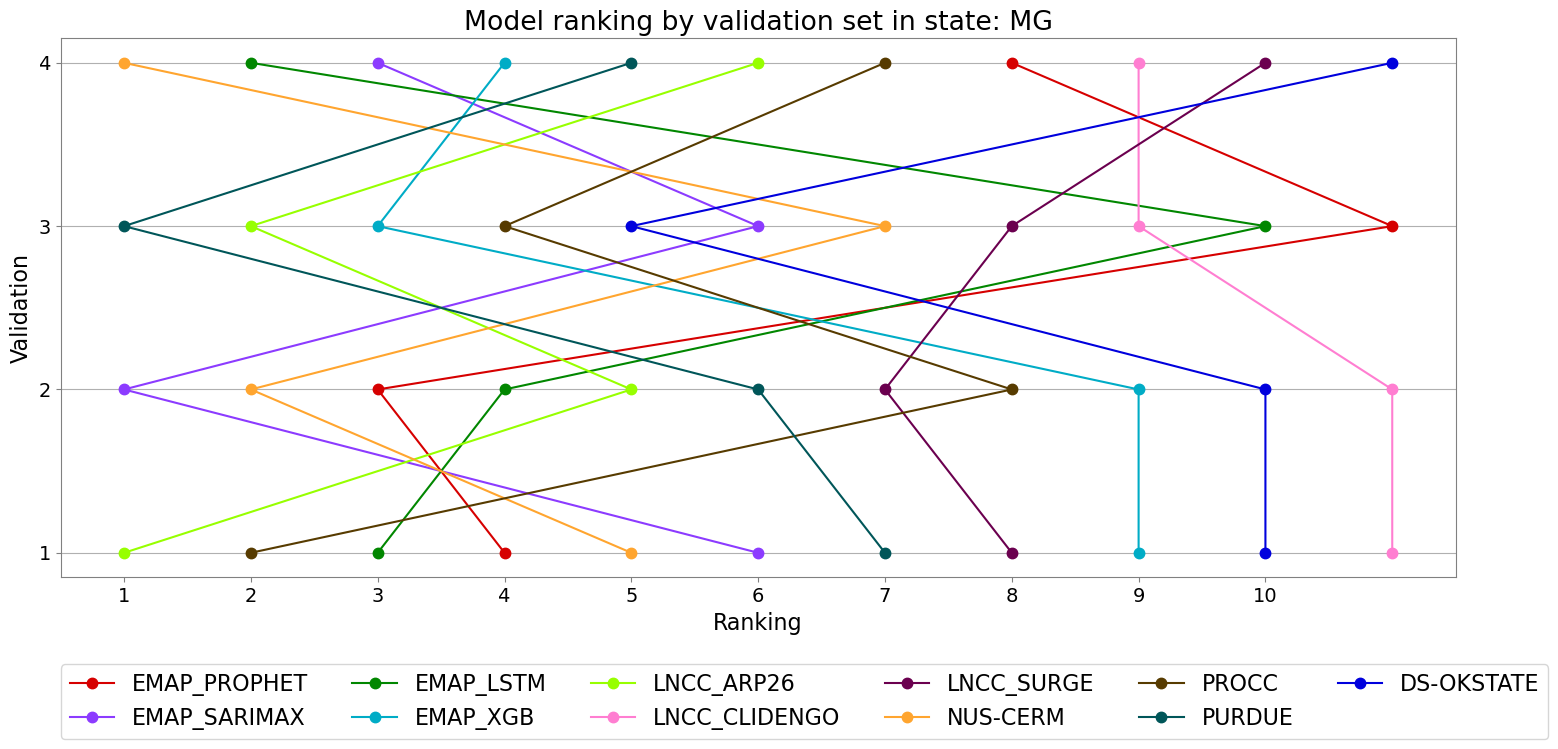

In [41]:
state = 31
plot_model_validation(
    df=df_rank,
    colors=colors,
    x_col="rank",
    x_label="Ranking",
    title="Model ranking by validation set",
    state=state,
    x_ticks=np.arange(1, 11),
)

### Violin plots

In [42]:
def plot_violin(df_rank, region = None): 

    if region is not None: 
        df_rank = df_rank.loc[df_rank.region == region]
    Q1 = df_rank["wis_ratio"].quantile(0.25)
    Q3 = df_rank["wis_ratio"].quantile(0.75)
    IQR = Q3 - Q1

    df_filtrado = df_rank[
        (df_rank["wis_ratio"] >= Q1 - 1.5 * IQR) &
        (df_rank["wis_ratio"] <= Q3 + 1.5 * IQR)
    ]

    order = df_filtrado["model"].unique()

    # Mediana de cada modelo
    medianas = df_filtrado.groupby("model")["wis_ratio"].median()

    # Cria uma cor para cada modelo
    palette = {
        model: "tab:green" if medianas[model] < 1 else "tab:blue"
        for model in order
    }



    fig, ax = plt.subplots(figsize=(15, 5))

    sns.violinplot(
        data=df_filtrado,
        x="model",
        y="wis_ratio",
        inner=None,
        palette=palette,
        ax=ax,
    )

    sns.boxplot(
        data=df_filtrado,
        x="model",
        y="wis_ratio",
        width=0.15,
        showcaps=True,
        showfliers=False,
        boxprops={"facecolor": "none"},
        whiskerprops={"color": "black"},
        medianprops={"color": "white", "linewidth": 2},
        capprops={"color": "black"},
        ax=ax,
    )

    # Obtém os rótulos atuais
    labels = [
        fill(label.get_text().replace("_", " "), width=18).replace(" ", "\n")
        for label in ax.get_xticklabels()
    ]

    # Define posições e rótulos
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(labels, rotation=90, fontdict={'size': 12},  ha="center",
        va="top")

    ax.axhline(1, color = 'red', linestyle = '--')
    ax.set_ylabel('WIS_model/WIS_baseline')

    if region is not None: 
        ax.set_title(f'Ratio between WIS model and baseline in {region}')
    else: 
        ax.set_title('Ratio between WIS model and baseline')

    plt.tight_layout()

    if region is not None: 
        plt.savefig(f'figures/ratio_models_{region}_{challenge}.png', dpi = 400, bbox_inches = 'tight')
    else: 
        plt.savefig(f'figures/ratio_models_{challenge}.png', dpi = 400, bbox_inches = 'tight')
    
    plt.show()

    return fig, ax 

In [43]:
def plot_swarmplot(df_rank, region = None): 

    if region is not None: 
        df_rank = df_rank.loc[df_rank.region == region]
    Q1 = df_rank["wis_ratio"].quantile(0.25)
    Q3 = df_rank["wis_ratio"].quantile(0.75)
    IQR = Q3 - Q1

    df_filtrado = df_rank[
        (df_rank["wis_ratio"] >= Q1 - 1.5 * IQR) &
        (df_rank["wis_ratio"] <= Q3 + 1.5 * IQR)
    ]

    order = df_filtrado["model"].unique()

    # Mediana de cada modelo
    medianas = df_filtrado.groupby("model")["wis_ratio"].median()

    # Cria uma cor para cada modelo
    palette = {
        model: "tab:green" if medianas[model] < 1 else "tab:blue"
        for model in order
    }



    fig, ax = plt.subplots(figsize=(15, 5))

    sns.stripplot(
        data=df_filtrado,
        x="model",
        y="wis_ratio",
        hue="validation",
        palette="tab10",      # ou "viridis", "tab10", etc.
        dodge=False,         # True separa horizontalmente por validation
        size=3.5,
        alpha=0.8,
        ax=ax
    )

    sns.boxplot(
        data=df_filtrado,
        x="model",
        y="wis_ratio",
        width=0.15,
        showcaps=True,
        showfliers=False,
        boxprops={"facecolor": "none"},
        whiskerprops={"color": "black"},
        medianprops={"color": "white", "linewidth": 2},
        capprops={"color": "black"},
        ax=ax,
        zorder = 5
    )

    # Obtém os rótulos atuais
    labels = [
        fill(label.get_text().replace("_", " "), width=18).replace(" ", "\n")
        for label in ax.get_xticklabels()
    ]

    # Define posições e rótulos
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(labels, rotation=90, fontdict={'size': 12},  ha="center",
        va="top")

    ax.axhline(1, color = 'red', linestyle = '--')
    ax.set_ylabel('WIS_model/WIS_baseline')

    if region is not None: 
        ax.set_title(f'Ratio between WIS model and baseline in {region}')
    else: 
        ax.set_title('Ratio between WIS model and baseline')

    ax.legend(loc= (1.01, 0.6))
    #plt.tight_layout()

    #if region is not None: 
    #    plt.savefig(f'figures/ratio_models_{region}.png', dpi = 400, bbox_inches = 'tight')
    #else: 
    #    plt.savefig('figures/ratio_models.png', dpi = 400, bbox_inches = 'tight')
    
    #plt.show()

    return fig, ax 

/tmp/ipykernel_6101/2822293738.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


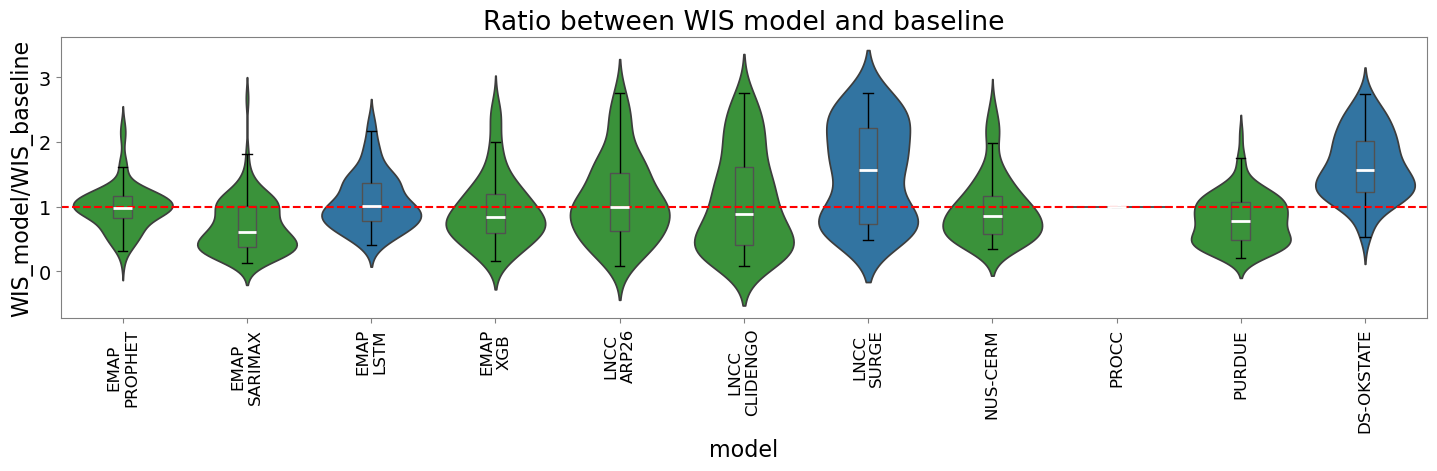

(<Figure size 1500x500 with 1 Axes>,
 <Axes: title={'center': 'Ratio between WIS model and baseline'}, xlabel='model', ylabel='WIS_model/WIS_baseline'>)

In [44]:
plot_violin(df_rank, region = None)

/tmp/ipykernel_6101/2822293738.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


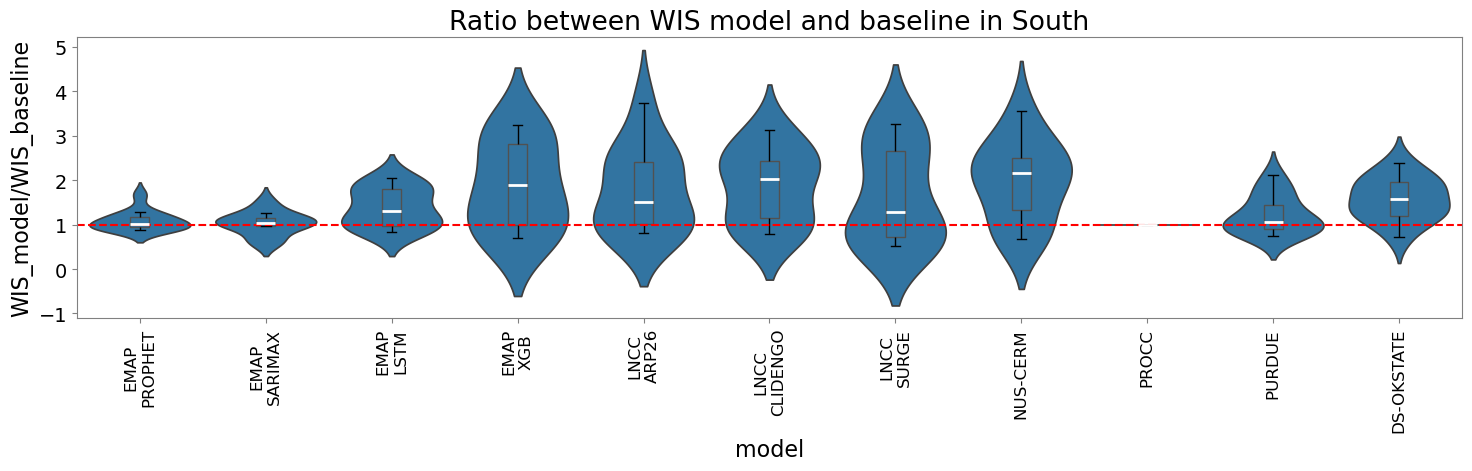

/tmp/ipykernel_6101/2822293738.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


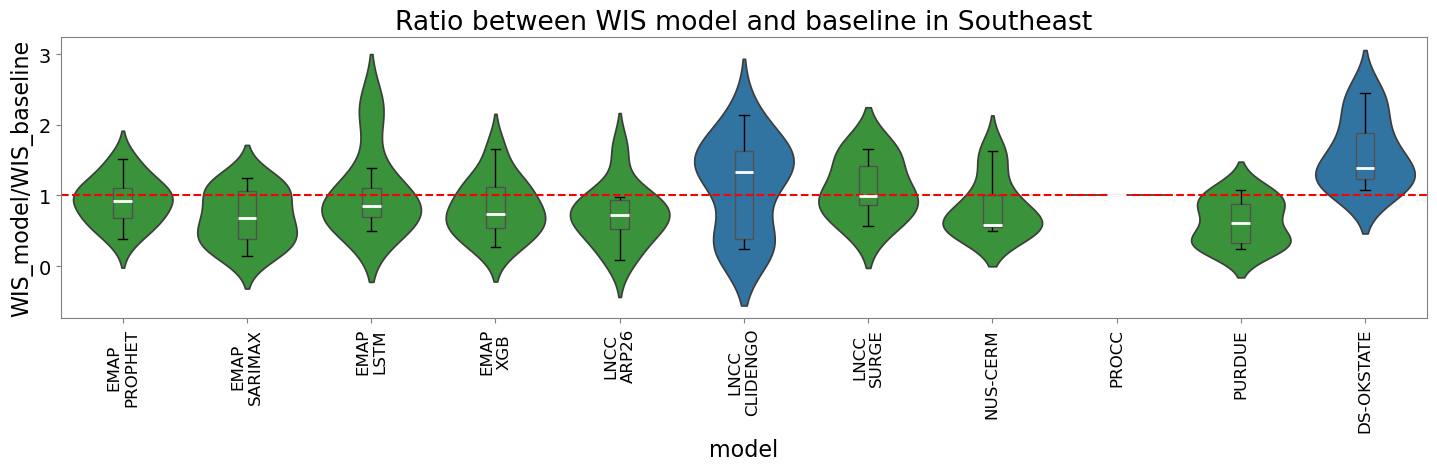

/tmp/ipykernel_6101/2822293738.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


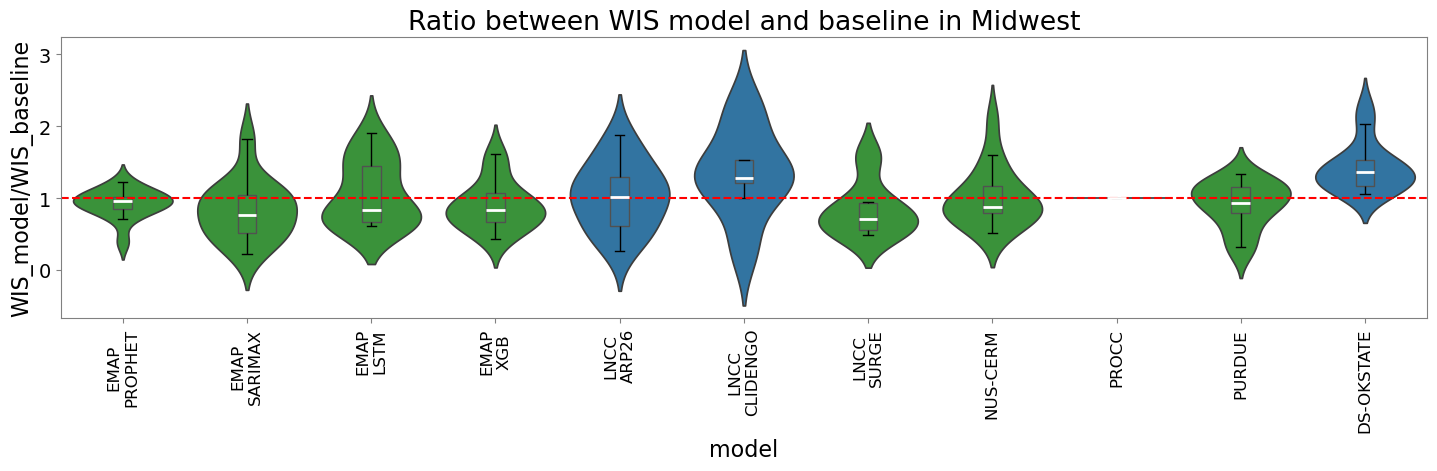

/tmp/ipykernel_6101/2822293738.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


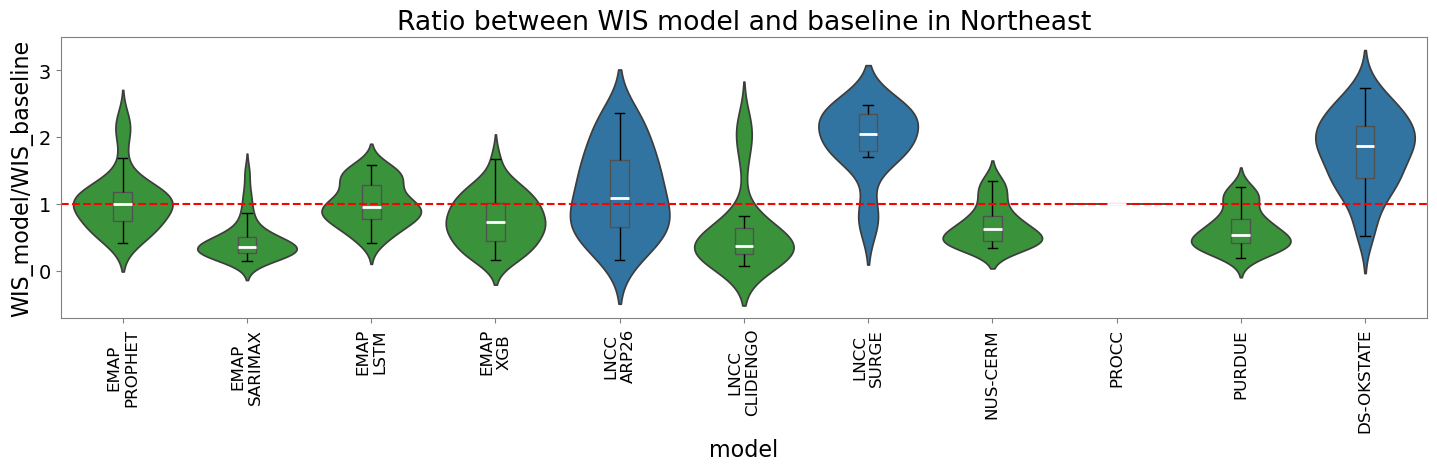

/tmp/ipykernel_6101/2822293738.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


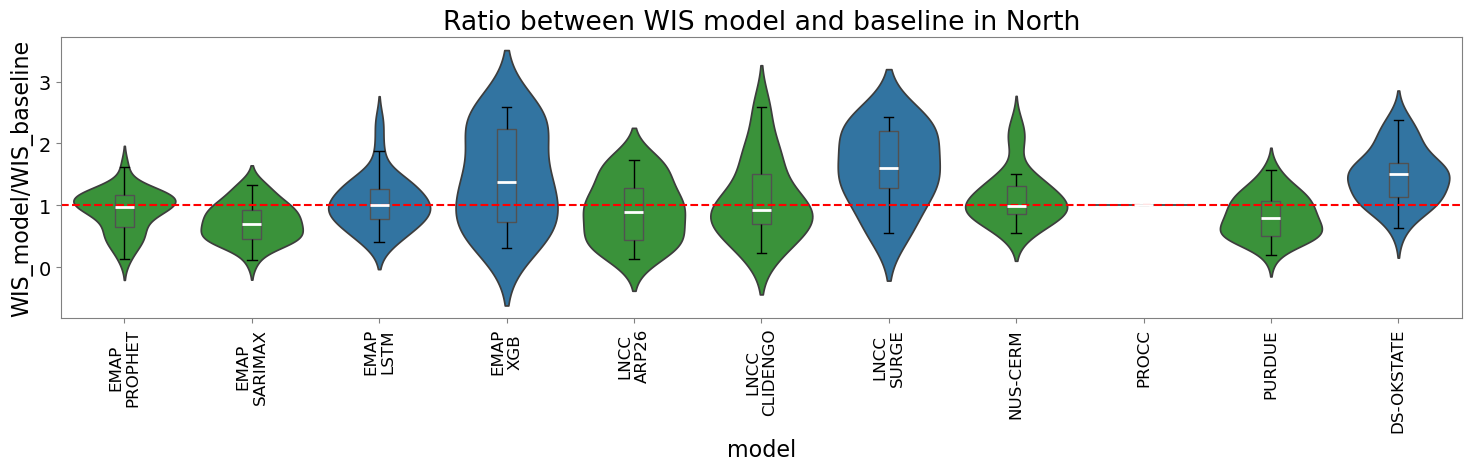

(<Figure size 1500x500 with 1 Axes>,
 <Axes: title={'center': 'Ratio between WIS model and baseline in North'}, xlabel='model', ylabel='WIS_model/WIS_baseline'>)

In [45]:
plot_violin(df_rank, region = 'South')
plot_violin(df_rank, region = 'Southeast')
plot_violin(df_rank, region = 'Midwest')
plot_violin(df_rank, region = 'Northeast')
plot_violin(df_rank, region = 'North')

### Comp distributions - max cases, peak cases and peak height:

In [46]:
df_true_params = pd.read_csv(f'data/parameters_{challenge}.csv.gz')

df_true_params.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/parameters_chik_state.csv.gz'

In [47]:
df_pars = pd.read_csv(f'predictions/new_metrics_{challenge}.csv.gz')
df_pars['model'] = df_pars['model'].replace(rename_models)
df_pars.head()

FileNotFoundError: [Errno 2] No such file or directory: 'predictions/new_metrics_chik_state.csv.gz'

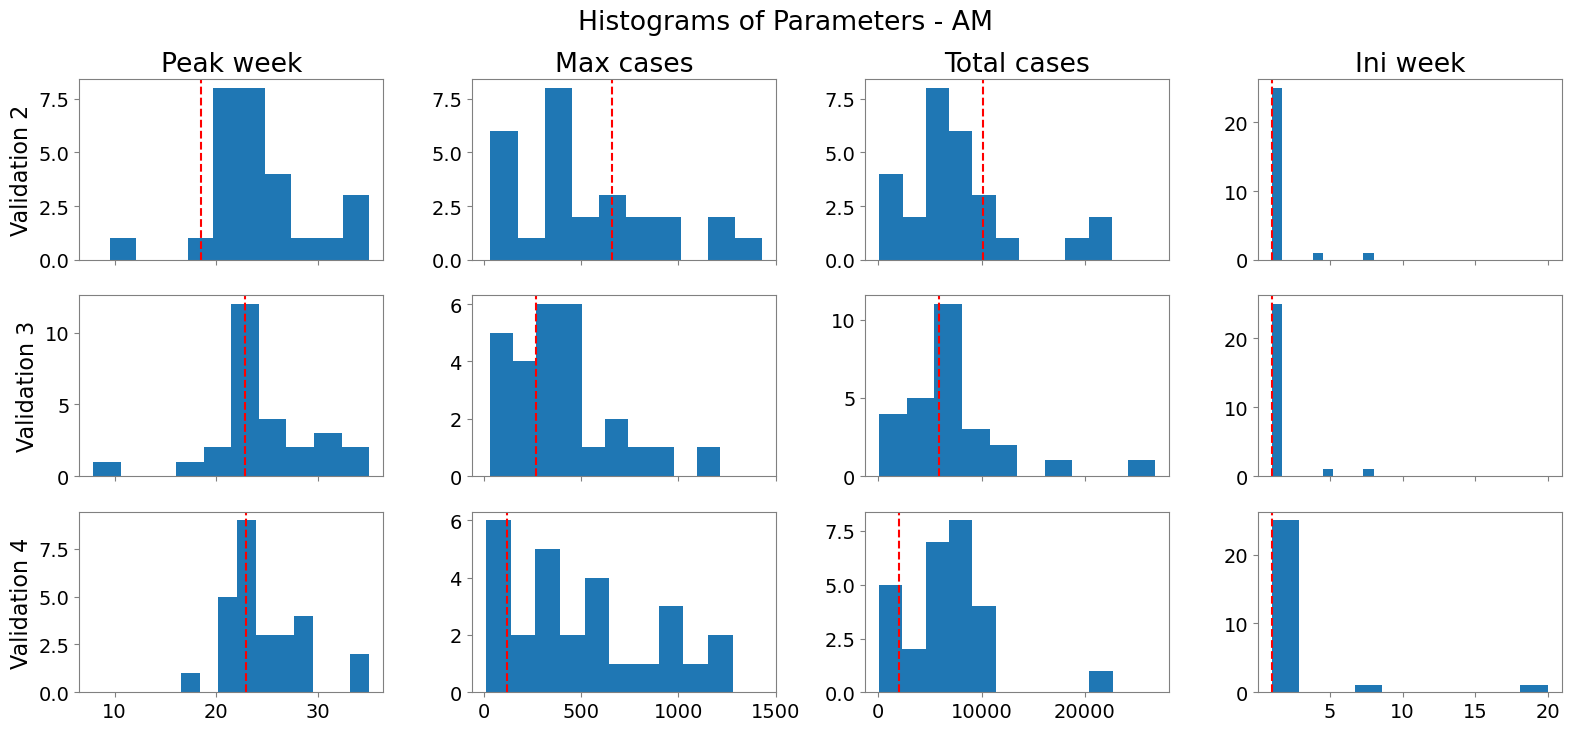

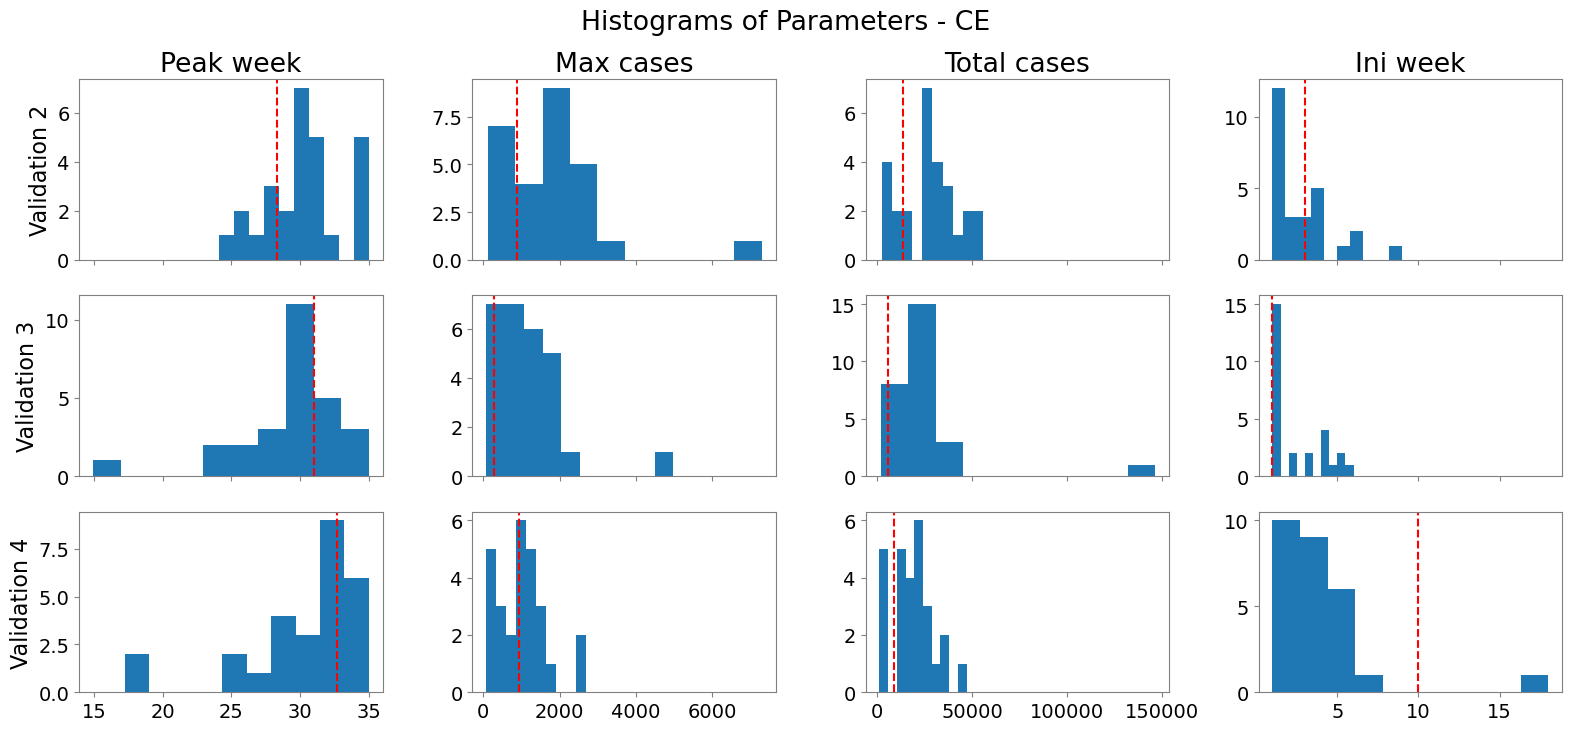

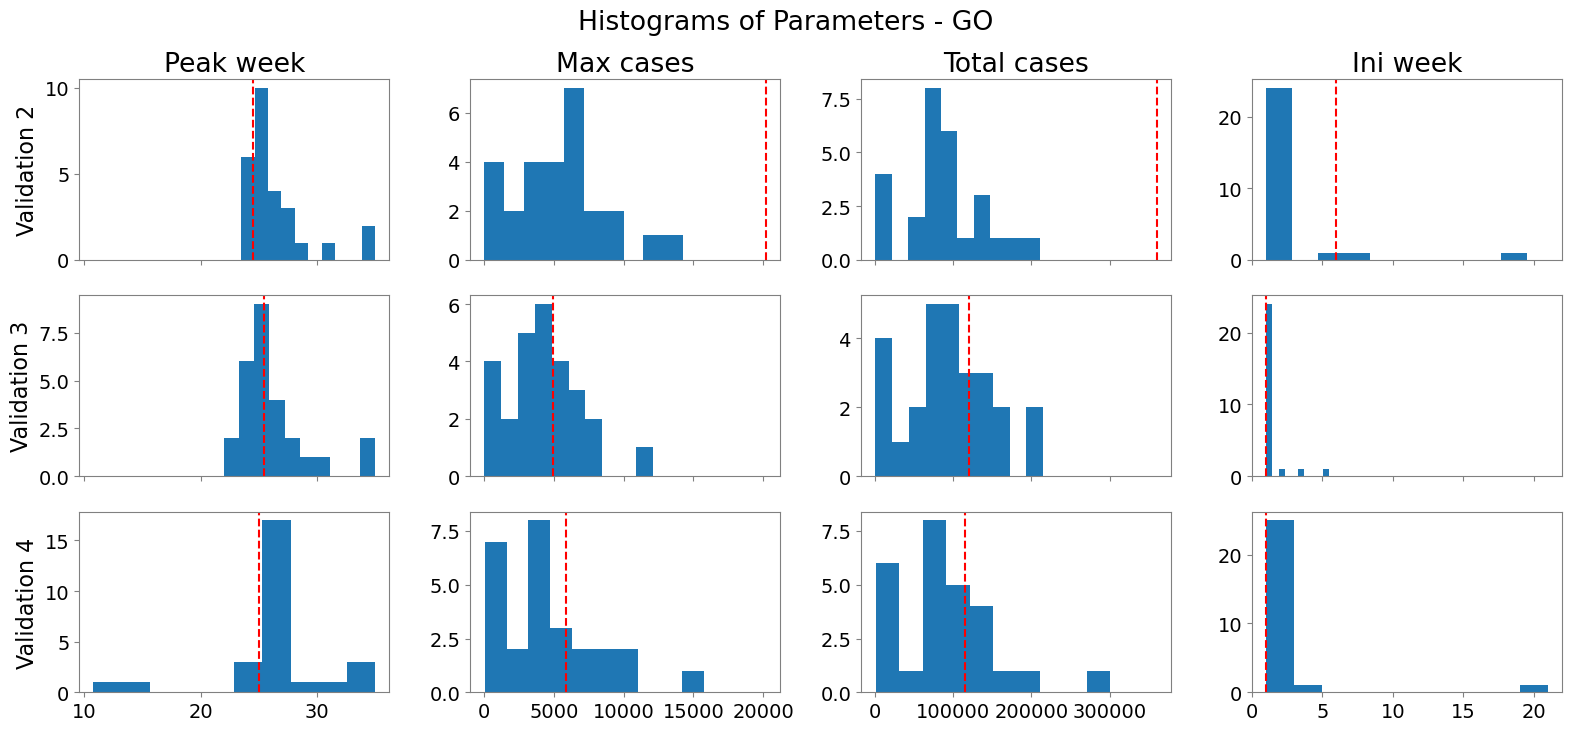

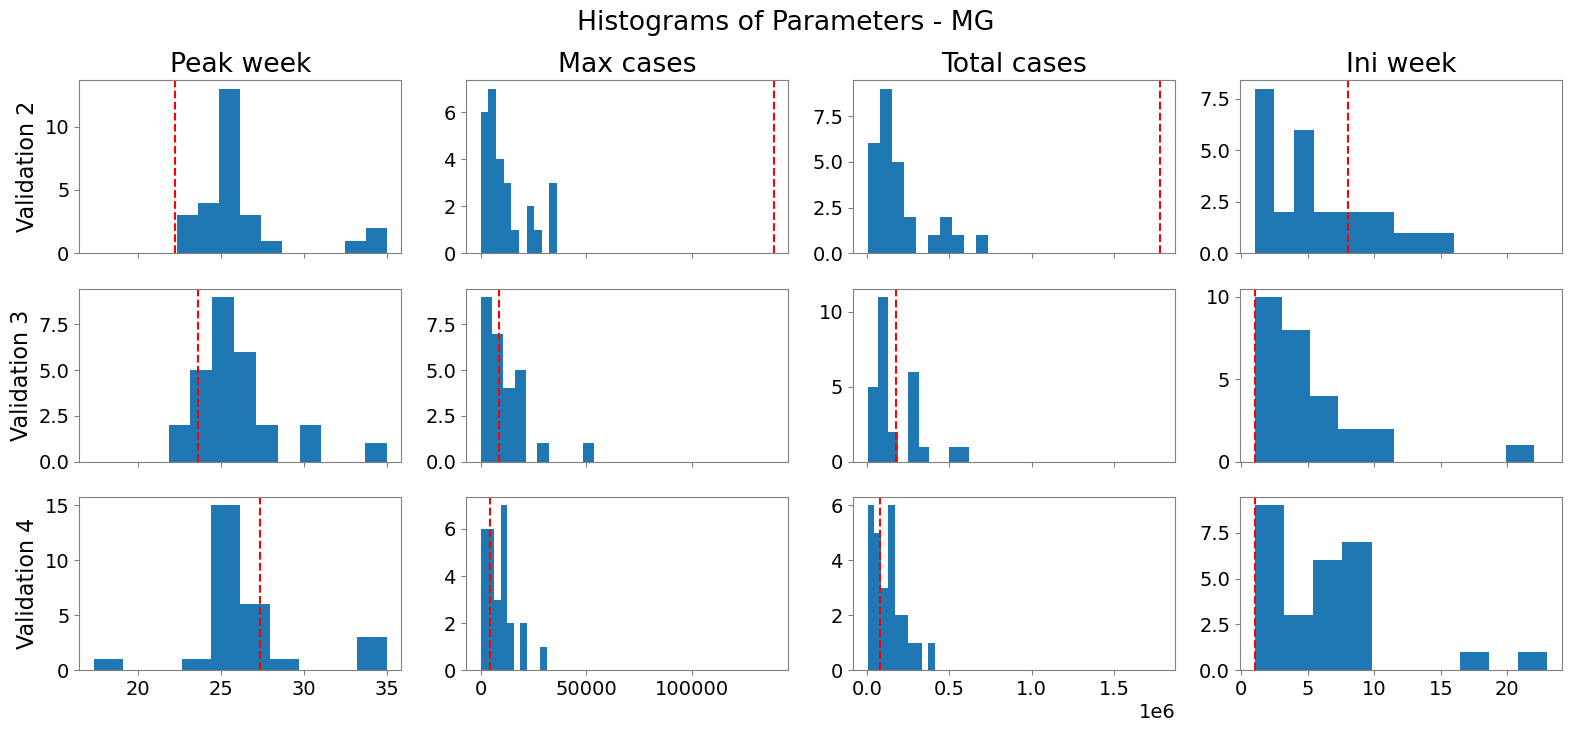

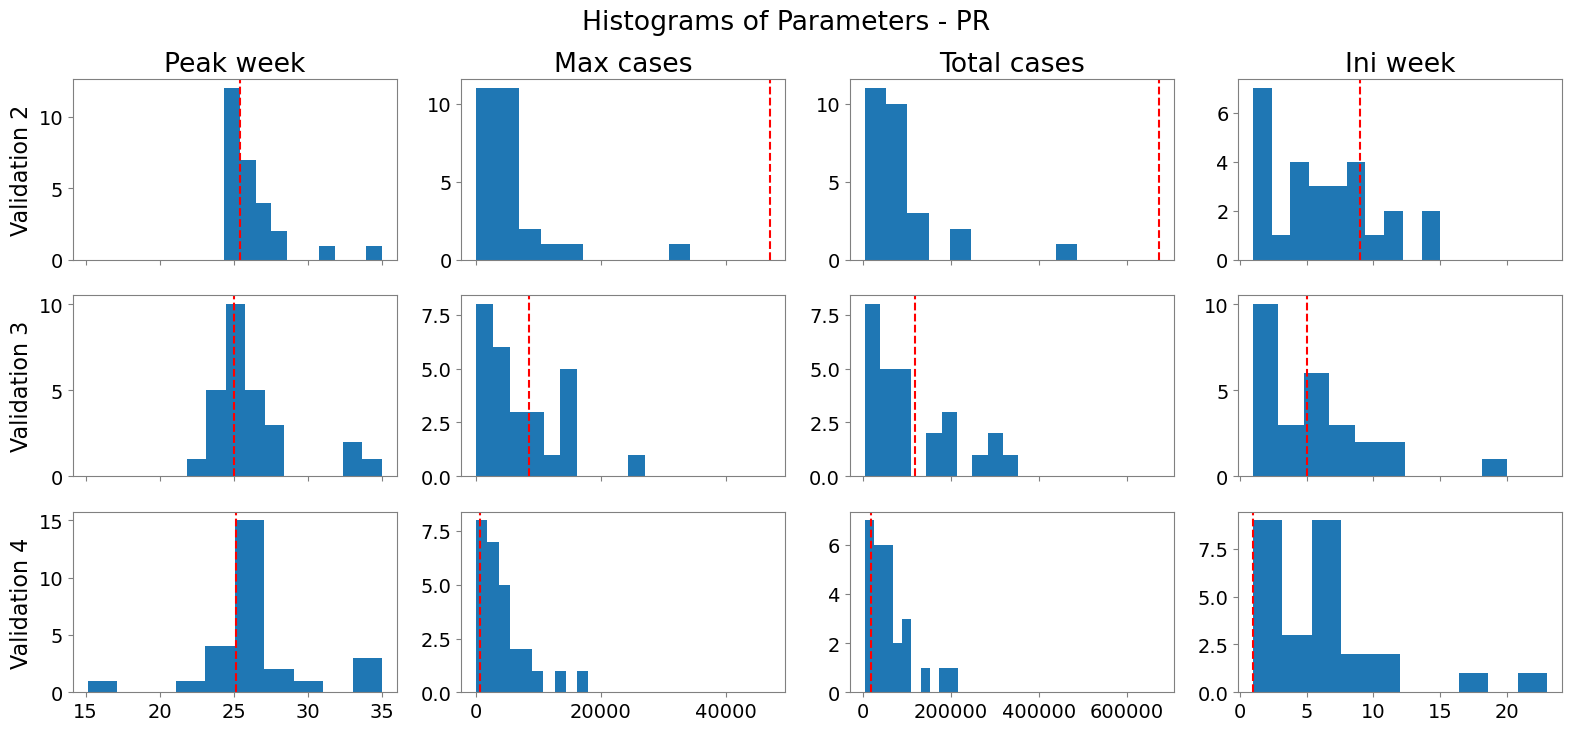

In [ ]:
def plot_parameters(ax, df_true_params, df_pars, state, val, column = 'peak_week', title = ''): 

    if column == 'peak_week': 
        label = 'pico_dist_p50'

    elif column == 'total_cases': 
        label = 'season_total_p50'
    
    elif column == 'peak_height': 
        label = 'season_peak_p50'

    elif column == 't_ini':
        label = 't_ini_dist_p50'

    df_true_ = df_true_params.loc[(df_true_params.state == state) & (df_true_params.validation == val)]

    df_pars_ = df_pars.loc[(df_pars.state == state) & (df_pars.validation == val )]

    ax.hist(df_pars_[label])
    ax.axvline(df_true_[column].values[0], color = 'red', linestyle = '--', label= 'Observed')

    ax.set_title(title)


def plot_parameter_histograms(
    df_true_params,
    df_pars,
    state,
    code_to_state,
    validations=(2, 3, 4),
    parameters=(
        ("peak_week", "Peak week"),
        ("peak_height", "Max cases"),
        ("total_cases", "Total cases"),
        ("t_ini", 'Ini week')
    ),
    figsize=(16, 8),
):
    """
    Plot histograms comparing estimated and true parameters for multiple
    validation sets.

    Parameters
    ----------
    df_true_params : pandas.DataFrame
        DataFrame containing the reference parameters.
    df_pars : pandas.DataFrame
        DataFrame containing the estimated parameters.
    state : int
        State code.
    code_to_state : dict
        Dictionary mapping state codes to state names.
    validations : iterable of int, optional
        Validation IDs to plot.
    parameters : iterable of tuple(str, str), optional
        List of (column_name, title).
    figsize : tuple, optional
        Figure size.
    """

    n_rows = len(validations)
    n_cols = len(parameters)

    fig, ax = plt.subplots(
        n_rows,
        n_cols,
        figsize=figsize,
        sharex="col",
        squeeze=False,
    )

    for i, val in enumerate(validations):
        ax[i, 0].set_ylabel(f"Validation {val}")

        for j, (column, title) in enumerate(parameters):
            plot_parameters(
                ax=ax[i, j],
                df_true_params=df_true_params,
                df_pars=df_pars,
                state=state,
                val=val,
                column=column,
                title=title if i == 0 else "",
            )

    fig.suptitle(f"Histograms of Parameters - {code_to_state[state]}", y = 0.92)
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    return fig, ax


for state in [13, 23, 52, 31, 41 ]:

    fig, ax = plot_parameter_histograms(df_true_params,
        df_pars,
        state =state, code_to_state=code_to_state)
    
    plt.savefig(f'figures/hist_pars_{state}_{challenge}.png', dpi = 400, bbox_inches = 'tight')
    

In [39]:
def plot_par_bar(ax, column, adm_1, validation, df_pars, df_true_params): 

    if column == 'peak_week': 
        label = 'pico_dist_p50'
        title = 'Peak week'

    elif column == 'total_cases': 
        label = 'season_total_p50'
        title = 'Total cases'
        
    elif column == 'peak_height': 
        label = 'season_peak_p50'
        title = 'Max cases'

    elif column == 't_ini':
        label = 't_ini_dist_p50'
        title = 'Start week'


    df_ = df_pars.loc[(df_pars.state == adm_1) & (df_pars.validation == validation)]

    ax.bar(df_.model, df_[label])
    ax.axhline(df_true_params.loc[(df_true_params.state == adm_1) & (df_true_params.validation == validation)][column].values[0],
            color = 'tab:red', linestyle = '--')

    ax.set_ylabel(title)
    plt.tight_layout()

    ax.set_title(f'{title} - state:{state}, validation:{validation}')


In [ ]:
adm_1 = 33 
validation = 2

for adm_1 in df_pars.state.unique(): 

    for validation in [2,3,4]: 

        _,ax = plt.subplots(4,1, figsize = (15, 9), sharex= True)


        plot_par_bar(ax[0], 'peak_week', adm_1, validation, df_pars, df_true_params)

        plot_par_bar(ax[1], 't_ini', adm_1, validation, df_pars, df_true_params)

        plot_par_bar(ax[2], 'peak_height', adm_1, validation, df_pars, df_true_params)

        plot_par_bar(ax[3], 'total_cases', adm_1, validation, df_pars, df_true_params)

        labels = [tick.get_text() for tick in ax[3].get_xticklabels()]

        labels = [label.replace("_", "\n", 1) for label in labels]
        ax[3].set_xticklabels(labels)

        ax[3].tick_params(axis='x', labelrotation=90)

        plt.savefig(f'figures/bar_pars_{adm_1}_{validation}_{challenge}.png', dpi = 300, bbox_inches = 'tight')

        plt.close()

/tmp/ipykernel_85759/4058111792.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[3].set_xticklabels(labels)
/tmp/ipykernel_85759/4058111792.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[3].set_xticklabels(labels)
/tmp/ipykernel_85759/4058111792.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[3].set_xticklabels(labels)
/tmp/ipykernel_85759/4058111792.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[3].set_xticklabels(labels)
/tmp/ipykernel_85759/4058111792.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[3].set_xticklabels(labels)
/tmp/